In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df=pd.read_csv("weight-height.csv")

In [3]:
df.head()

,Height,Weight
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'height')

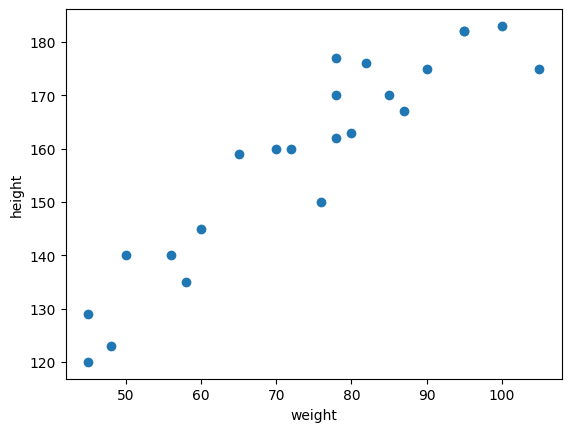

In [4]:
## scatter plot
plt.scatter(df['Height'],df['Weight'])
plt.xlabel('weight')
plt.ylabel('height')

In [5]:
## correlation
df.corr()

,Height,Weight
Height,1.000000,0.931142
Weight,0.931142,1.000000


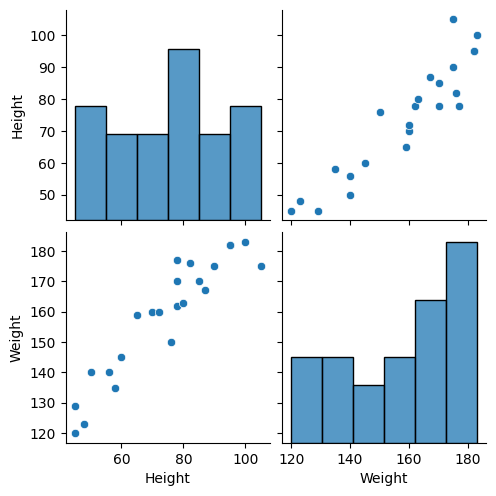

In [6]:
## seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [7]:
## independent and dependent features
x=df[['Weight']]     ## independent features should be data frame or 2 dimention
y=df[['Height']]     ## this variable can be in series or 1D array

In [8]:
x_series=df['Weight']
np.array(x_series).shape

(23,)

In [9]:
np.array(y).shape

(23, 1)

In [10]:
## train test split
from sklearn.model_selection import train_test_split

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [12]:
x_train.shape

(17, 1)

In [13]:
## standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()    
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [14]:
x_test

array([[ 1.13884569],
       [ 0.75052868],
       [-2.02316426],
       [ 1.41621498],
       [ 0.14031623],
       [ 1.02789797]])

In [15]:
## apply linear regression
from sklearn.linear_model import LinearRegression

regression = LinearRegression(n_jobs=-1)
regression.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
print("coefficient or slope:",regression.coef_)
print("intercept:",regression.intercept_)

coefficient or slope: [[15.84018607]]
intercept: [72.47058824]


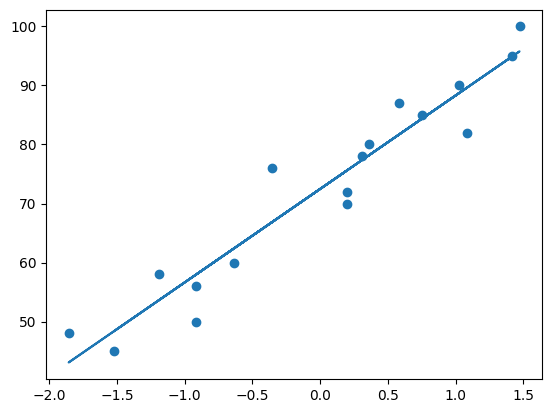

In [18]:
## plot training data plot best fit line
plt.scatter(x_train,y_train)
plt.plot(x_train,regression.predict(x_train))